In [1]:
from functools import reduce, partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg

In [2]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2


import plotting as pl
from models import model as md
import utils as ut

In [20]:
# by-participant embedding models (no by-participant decision models
l_lmbda = [1e-07]
l_data_subset = ["full_evaluate_actual"]
l_rnd_seed = [1]
l_embed_dim = [5, 15]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"
l_id_type = ["separate", "shared", "shared_and_separate"]

l_id_weights, l_results_agg = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda,
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype, l_id_weights_type=l_id_type
                                                          )


In [23]:
test_accs_max = np.array([np.max(l["test_accs_max"]) for l in l_id_weights])
n_embed = np.array([l["n_embed"] for l in l_id_weights])
dimweight_type = np.array([l["id_weights_type"] for l in l_id_weights])
df_results = pd.DataFrame({
    "ArgMax":test_accs_max,
    "Nr. Dim.":n_embed,
    "Dimension Weights":dimweight_type
})

In [46]:
df_results["Dimension Weights"] = df_results["Dimension Weights"].astype("category")
df_results["Dimension Weights"] = df_results["Dimension Weights"].cat.rename_categories(
    ["Separate", "Shared", "Shared & Separate"]
)

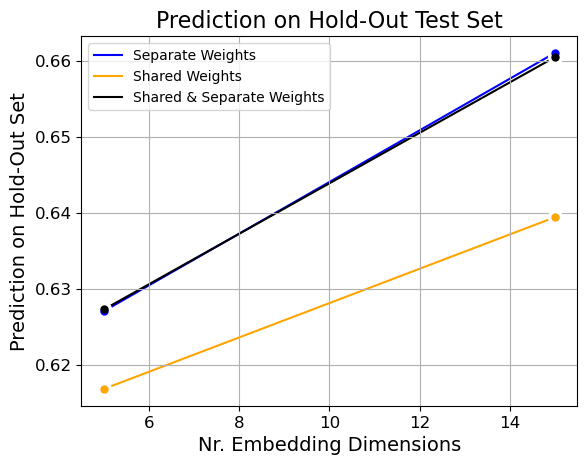

In [51]:
f, ax = plt.subplots(1)

ax.scatter(df_results["Nr. Dim."], df_results["ArgMax"], c="white", s=100, zorder=2)
idx=0

ax.grid(True, zorder=0)

for weighttype, group_df in df_results.groupby("Dimension Weights", observed=True):
    ax.plot(
        group_df["Nr. Dim."],
        group_df["ArgMax"],
        label=f"{weighttype} Weights",
        zorder=1,
        c=["blue", "orange", "black"][idx]
    )
    ax.scatter(group_df["Nr. Dim."], group_df["ArgMax"], s=25, zorder=3, c=["blue", "orange", "black"][idx])
    idx += 1

ax.set_title("Prediction on Hold-Out Test Set")

ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel("Nr. Embedding Dimensions", fontsize=14)
ax.set_ylabel("Prediction on Hold-Out Set", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)
_ = ax.legend(title="")